In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import corner

from bilby.gw.conversion import lambda_1_lambda_2_to_lambda_tilde, lambda_1_lambda_2_to_delta_lambda_tilde, lambda_tilde_delta_lambda_tilde_to_lambda_1_lambda_2

In [2]:
narrow_df = pd.read_csv("../../events/gw/gw_params_narrow.dat", sep=" ")
detection_df = pd.read_csv("../../events/detection/detection_output/narrow_ETL.dat", sep=" ")
events = pd.read_csv("events.dat", sep=" ")
events["mass_ratio"] = events["mass_2"] / events["mass_1"]

In [3]:
n_coll = np.sum(events["prompt_collapse"] ==1 )
n_tot = events.shape[0]
pop_coll_share = np.sum(narrow_df["prompt_collapse"]==1)/narrow_df.shape[0]

print(f"Prompt collapse: {n_coll}/{n_tot}, {n_coll/n_tot:.3f}, ", pop_coll_share)

Prompt collapse: 2/87, 0.023,  0.09623246050160203


In [4]:
log10_mej_wind = events["log10_mej_wind"]
zeta = 10**(events["log10_mej_wind"] - events["log10_mdisk"])

print("wind quantile: ", np.quantile(log10_mej_wind, 0.05))
print("zeta quantile: ", np.quantile(zeta, 0.05))

wind quantile:  -1.4870340250450704
zeta quantile:  0.22598113402827733


In [5]:
print("SNR min max: ", np.min(events["snr"]), np.max(events["snr"]))

SNR min max:  13.101 238.636


In [6]:
events["log10_mej_wind"].argmin()

np.int64(33)

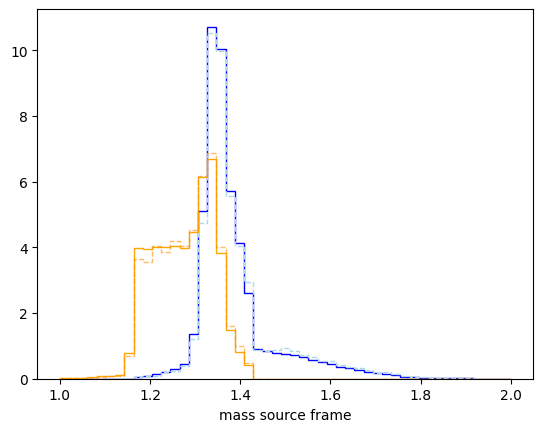

In [7]:
bins = np.linspace(1, 2, 50)

plt.hist(narrow_df["mass_1_source"], bins=bins, density=True, histtype="step", color="blue")
plt.hist(narrow_df.loc[detection_df["gw_detected"].astype(bool), "mass_1_source"], bins=bins, density=True, histtype="step", color="lightblue", linestyle="dashed")

plt.hist(narrow_df["mass_2_source"], bins=bins, density=True, color="orange", histtype="step")
plt.hist(narrow_df.loc[detection_df["gw_detected"].astype(bool), "mass_2_source"], bins=bins, density=True, histtype="step", alpha=0.6, color="darkorange", linestyle="dashed")


plt.xlabel("mass source frame")
plt.show()

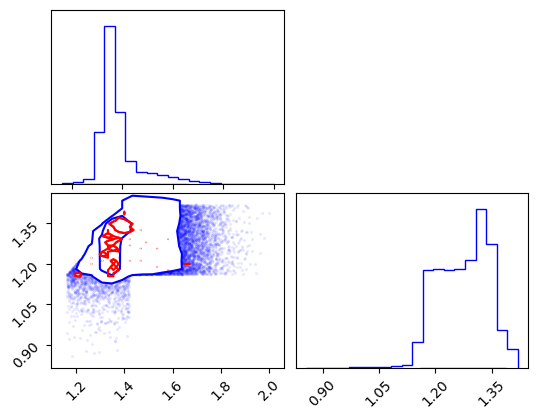

In [8]:
fig, ax = plt.subplots(2,2)

corner.corner(np.array([narrow_df["mass_1_source"], narrow_df["mass_2_source"]]).T,
                       color="blue", fig=fig, plot_density=False, levels=[0.68, 0.95])

corner.corner(np.array([events["mass_1_source"], events["mass_2_source"]]).T,
                       color="red", fig=fig, plot_density=False, levels=[0.68, 0.95])

fig.show()

(array([ 8., 11., 10.,  8.,  7., 10., 12., 11.,  5.,  5.]),
 array([0.20001408, 0.21998771, 0.23996134, 0.25993496, 0.27990859,
        0.29988222, 0.31985585, 0.33982947, 0.3598031 , 0.37977673,
        0.39975036]),
 [<matplotlib.patches.Polygon at 0x7f3562f447d0>])

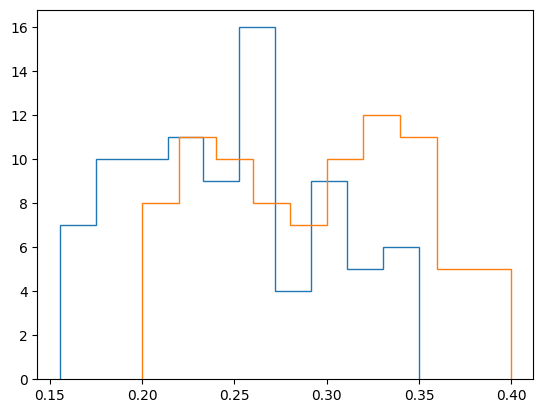

In [9]:
plt.hist(events.loc[:, "Ye_dyn"], histtype="step")
plt.hist(events.loc[:, "Ye_wind"], histtype="step")



(array([ 1.,  1.,  6., 14., 19., 10., 25.,  9.,  1.,  1.]),
 array([0.16675879, 0.17265789, 0.17855699, 0.18445609, 0.19035519,
        0.19625429, 0.20215338, 0.20805248, 0.21395158, 0.21985068,
        0.22574978]),
 [<matplotlib.patches.Polygon at 0x7f3562fc0cd0>])

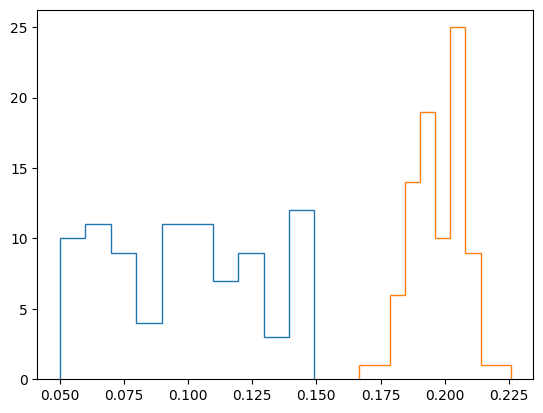

In [10]:
plt.hist(events.loc[:, "v_ej_wind"], histtype="step")
plt.hist(events.loc[:, "v_ej_dyn"], histtype="step")


(array([4.69294362e-03, 4.05801595e-02, 1.55143195e-01, 3.92550931e-01,
        7.15259819e-01, 1.06419398e+00, 2.58056688e+00, 4.91047536e+00,
        6.61870684e+00, 8.50361384e+00]),
 array([0.5997643 , 0.63978706, 0.67980982, 0.71983258, 0.75985534,
        0.79987809, 0.83990085, 0.87992361, 0.91994637, 0.95996913,
        0.99999189]),
 [<matplotlib.patches.Polygon at 0x7f3562e2a7d0>])

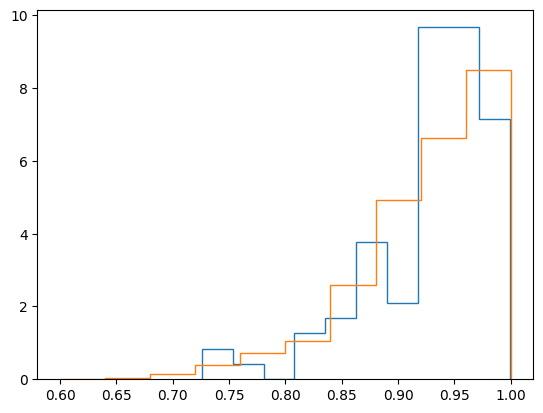

In [11]:
plt.hist(events["mass_ratio"], density=True, histtype="step")
plt.hist(narrow_df["mass_2"] / narrow_df["mass_1"], density=True, histtype="step")

(array([9.83281365e-04, 1.37659391e-02, 1.01769621e-01, 1.88478650e+00,
        3.28924005e+00, 1.59193253e+00, 3.94459708e-01, 1.19632566e-01,
        1.84365256e-02, 1.39298193e-03]),
 array([2.03970241, 2.17453872, 2.30937504, 2.44421135, 2.57904767,
        2.71388398, 2.84872029, 2.98355661, 3.11839292, 3.25322924,
        3.38806555]),
 [<matplotlib.patches.Polygon at 0x7f3563ffc6d0>])

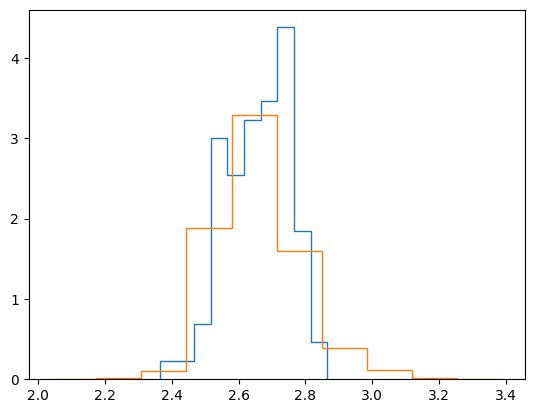

In [12]:
plt.hist(events["mass_2_source"] + events["mass_1_source"], density=True, histtype="step")
plt.hist(narrow_df["mass_2_source"] + narrow_df["mass_1_source"], density=True, histtype="step")

(array([31., 16., 11., 12.,  6.,  5.,  3.,  1.,  1.,  1.]),
 array([ 277.72178136,  652.36690431, 1027.01202727, 1401.65715022,
        1776.30227317, 2150.94739612, 2525.59251907, 2900.23764203,
        3274.88276498, 3649.52788793, 4024.17301088]),
 <BarContainer object of 10 artists>)

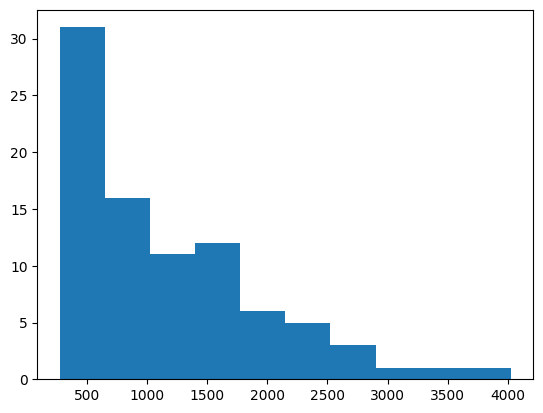

In [13]:
plt.hist(events["luminosity_distance"])